In [2]:
import pandas as pd

df=pd.read_csv("../data/application_train.csv")
print(df.head())
print(" ")
print(df.tail())

   SK_ID_CURR  TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR  \
0      100002       1         Cash loans           M            N   
1      100003       0         Cash loans           F            N   
2      100004       0    Revolving loans           M            Y   
3      100006       0         Cash loans           F            N   
4      100007       0         Cash loans           M            N   

  FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  \
0               Y             0          202500.0    406597.5      24700.5   
1               N             0          270000.0   1293502.5      35698.5   
2               Y             0           67500.0    135000.0       6750.0   
3               Y             0          135000.0    312682.5      29686.5   
4               Y             0          121500.0    513000.0      21865.5   

   ...  FLAG_DOCUMENT_18 FLAG_DOCUMENT_19 FLAG_DOCUMENT_20 FLAG_DOCUMENT_21  \
0  ...                 0             

In [3]:
print(df.shape)

(307511, 122)


### Observation: Dataset Shape

- The dataset contains **307,511 loan applications**.
- It consists of **122 attributes**, including demographic, financial, credit history, and behavioral information.
- The target variable is `TARGET`, which indicates whether the applicant experienced payment difficulties (1) or repaid the loan successfully (0).

In [4]:
print(df.columns)

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='str', length=122)


### Observation: Dataset Features

- The dataset contains **122 attributes** describing loan applicants.
- Features include demographic information, income, employment, education, housing, family details, credit amount, annuity, external credit scores, and bureau inquiry history.
- The dataset also contains a binary target variable (`TARGET`) indicating whether the applicant experienced payment difficulties.
- `SK_ID_CURR` serves as a unique identifier for each loan application and will not be used as a predictive feature.

In [5]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), str(16)
memory usage: 286.2 MB
None


### Dataset Information

- The dataset contains **307,511 loan applications** with **122 features**.
- The dataset occupies approximately **286.2 MB** of memory.
- There are **65 floating-point**, **41 integer**, and **16 categorical (string)** features.
- The presence of multiple data types indicates that preprocessing techniques such as missing value handling, categorical encoding, and feature scaling will be required before model training.

## 8. Target Variable Analysis

The `TARGET` variable represents the loan repayment outcome:

- `0` — Applicant did not experience payment difficulties.
- `1` — Applicant experienced payment difficulties.

In [6]:
df["TARGET"].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

### Observation

The target variable is imbalanced. Approximately 91.9% of applicants belong to TARGET = 0, while only 8.1% belong to TARGET = 1. Therefore, model evaluation should not rely on accuracy alone, as accuracy may be misleading when predicting the minority default class.

In [7]:
!pip install matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


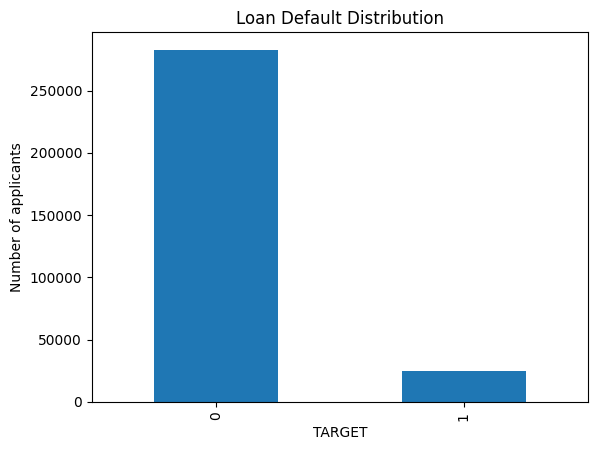

In [8]:
import matplotlib.pyplot as plt

df['TARGET'].value_counts().plot(kind="bar")
plt.xlabel("TARGET")
plt.ylabel("Number of applicants")
plt.title("Loan Default Distribution")
plt.show()

### Observation

The target distribution is highly imbalanced. The majority of applicants (TARGET = 0) did not experience payment difficulties, while a much smaller proportion (TARGET = 1) experienced payment difficulties. Therefore, model evaluation should consider metrics such as precision, recall, F1-score, and ROC-AUC rather than relying solely on accuracy.

In [9]:
missing=df.isnull().sum().sort_values(ascending=False)
missing[missing>0].head(20)

COMMONAREA_MEDI             214865
COMMONAREA_AVG              214865
COMMONAREA_MODE             214865
NONLIVINGAPARTMENTS_MODE    213514
NONLIVINGAPARTMENTS_AVG     213514
NONLIVINGAPARTMENTS_MEDI    213514
FONDKAPREMONT_MODE          210295
LIVINGAPARTMENTS_MODE       210199
LIVINGAPARTMENTS_AVG        210199
LIVINGAPARTMENTS_MEDI       210199
FLOORSMIN_AVG               208642
FLOORSMIN_MODE              208642
FLOORSMIN_MEDI              208642
YEARS_BUILD_MEDI            204488
YEARS_BUILD_MODE            204488
YEARS_BUILD_AVG             204488
OWN_CAR_AGE                 202929
LANDAREA_MEDI               182590
LANDAREA_MODE               182590
LANDAREA_AVG                182590
dtype: int64

### Missing Value Observation

Several features contain a substantial proportion of missing values. The highest missingness is observed in property-related features such as `COMMONAREA_MEDI`, `NONLIVINGAPARTMENTS_MODE`, and `YEARS_BUILD_MEDI`, as well as `OWN_CAR_AGE`.

These missing values may represent unavailable or unreported information rather than actual zero values. Therefore, an appropriate missing-value treatment strategy will be considered during the preprocessing stage.

In [10]:
missing_percent = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_percent.head(20)

COMMONAREA_MEDI             69.872297
COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
NONLIVINGAPARTMENTS_MEDI    69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_MODE       68.354953
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
FLOORSMIN_AVG               67.848630
FLOORSMIN_MODE              67.848630
FLOORSMIN_MEDI              67.848630
YEARS_BUILD_MEDI            66.497784
YEARS_BUILD_MODE            66.497784
YEARS_BUILD_AVG             66.497784
OWN_CAR_AGE                 65.990810
LANDAREA_MEDI               59.376738
LANDAREA_MODE               59.376738
LANDAREA_AVG                59.376738
dtype: float64

### Missing Value Observation

The dataset contains substantial missing values in several features. The highest missingness is observed in property-related attributes, with some features having more than 65% missing values. `COMMONAREA_MEDI`, for example, has approximately 69.87% missing values.

These features require careful treatment during preprocessing. Missing values will not be blindly replaced with mean values, as the appropriate strategy depends on the feature type, missingness level, and predictive relevance.

In [11]:
missing_percent.tail(20)

HOUR_APPR_PROCESS_START        0.0
WEEKDAY_APPR_PROCESS_START     0.0
REGION_RATING_CLIENT_W_CITY    0.0
REGION_RATING_CLIENT           0.0
FLAG_EMAIL                     0.0
FLAG_CONT_MOBILE               0.0
ORGANIZATION_TYPE              0.0
FLAG_WORK_PHONE                0.0
FLAG_EMP_PHONE                 0.0
FLAG_MOBIL                     0.0
DAYS_ID_PUBLISH                0.0
DAYS_REGISTRATION              0.0
DAYS_EMPLOYED                  0.0
DAYS_BIRTH                     0.0
REGION_POPULATION_RELATIVE     0.0
NAME_HOUSING_TYPE              0.0
NAME_FAMILY_STATUS             0.0
NAME_EDUCATION_TYPE            0.0
NAME_INCOME_TYPE               0.0
SK_ID_CURR                     0.0
dtype: float64

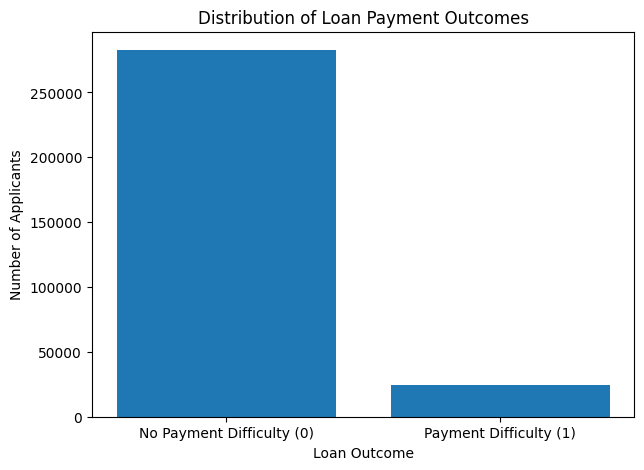

In [12]:
import matplotlib.pyplot as plt

target_counts = df["TARGET"].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(["No Payment Difficulty (0)", "Payment Difficulty (1)"],
        target_counts.values)

plt.title("Distribution of Loan Payment Outcomes")
plt.xlabel("Loan Outcome")
plt.ylabel("Number of Applicants")

plt.show()

### Missing Value Analysis - Observation

The dataset contains both complete and highly incomplete features. Several demographic, employment, and application-related features have no missing values, while certain property and asset-related features contain more than 60% missing values.

This variation indicates that a single missing-value treatment strategy may not be appropriate for all features. The preprocessing stage will therefore consider feature type and missing-value proportion when determining whether to impute or remove features.